<h1>Assessment 2 - Alternative Analysis Idea</h1>
Using the goalkeeper statistics from the FIFA World Cup 2026 dataset, compute an aggression ratio per tournament stage.
Where aggression is defined by goalkeeper defensive activity (actions inside + outside the penalty area relative to saves)
and calculate how this aggression metric evolves across the stages of the fifa world cup 2026.


* Goalkeepers are the proxy for aggression, because the dataset contains no fouls/cards.
* The ratio is explicitly tied to goalkeeper workload and defensive pressure.
* The goal is not just computing the ratio per match, but aggregating it per stage (group, R32, R16, QF, SF, Final).

The analysis is goalkeeper‑centric and not team‑centric.

<h4> Aggression = GK defensive workload under pressure </h4>

Step: 1
Aggression definition:
GK Aggression Ratio = GK Actions Inside PA + GK Actions Outside PA / GK Saves

This measures how busy and pressured a goalkeeper was relative to how many shots they actually stopped.

Step 2:
Code the average aggression per tournament stage 
- group
- round of 32
- round of 16
- quarter‑final
- semi‑final
- final


In [1]:
# Import required package
import pandas as pd

#Load csv's
rounds = pd.read_csv("rounds.csv")
teams = pd.read_csv("teams.csv")
gk = pd.read_csv("goalkeeper.csv")

# strip Team column in goalkeeper dataframe - remove abbreviations and whitespace
gk['Team'] = gk['Team'].str.strip()

# Merge goalkeeper stats with team id'
gk_stats = gk.merge(teams, left_on="Team", right_on="abbr")

In [2]:
gk_stats.info


<bound method DataFrame.info of      Rank             Player Team Position  Goalkeeper_Saves  \
0       1       Orlando Gill  PAR       GK                28   
1       2          Eloy Room  CUW       GK                21   
2       3  Emiliano Martinez  ARG       GK                20   
3       3       Gregor Kobel  SUI       GK                20   
4       3        Diogo Costa  POR       GK                20   
..    ...                ...  ...      ...               ...   
140    58     Geronimo Rulli  ARG       GK                 0   
141    58      Sergio Rochet  URU       GK                 0   
142    58           Weverton  BRA       GK                 0   
143    58       David Ospina  COL       GK                 0   
144    58     Gaston Olveira  PAR       GK                 0   

     Goalkeeper_Actions_inside_PenaltyArea  \
0                                      141   
1                                       81   
2                                      111   
3              

In [3]:
gk_stats.head()


,Rank,Player,Team,Position,Goalkeeper_Saves,Goalkeeper_Actions_inside_PenaltyArea,Goalkeeper_Actions_outside_PenaltyArea,id,name,abbr
0,1,Orlando Gill,PAR,GK,28,141,124,58,Paraguay,PAR
1,2,Eloy Room,CUW,GK,21,81,72,14,Curaçao,CUW
2,3,Emiliano Martinez,ARG,GK,20,111,97,2,Argentina,ARG
3,3,Gregor Kobel,SUI,GK,20,100,88,99,Switzerland,SUI
4,3,Diogo Costa,POR,GK,20,114,93,59,Portugal,POR


In [4]:
gk_stats.describe()

,Rank,Goalkeeper_Saves,Goalkeeper_Actions_inside_PenaltyArea,Goalkeeper_Actions_outside_PenaltyArea,id
count,145.000000,145.000000,145.000000,145.000000,145.000000
mean,46.082759,4.503448,28.268966,23.820690,46.462069
std,18.102526,6.669920,40.155125,33.727393,36.818817
min,1.000000,0.000000,0.000000,0.000000,1.000000
25%,36.000000,0.000000,0.000000,0.000000,13.000000
50%,58.000000,0.000000,0.000000,0.000000,48.000000
75%,58.000000,8.000000,55.000000,46.000000,60.000000
max,58.000000,28.000000,141.000000,124.000000,112.000000


In [5]:
# rename squad abbreviations in the round.csv
rounds = rounds.rename(columns={
    "homeSquadAbbr": " home_abbr",
    "awaySquadAbbr": "Away_abbr"
})

In [6]:
rounds.head()


,id,voteStatus,stage,roundName,votingStartDate,votingEndDate,votingOpenedAt,selectedFormation,winners,formations,...,homeSquadId,awaySquadId,homeSquadName,awaySquadName,home_abbr,Away_abbr,homeScore,awayScore,groupName,matchDay
0,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,52,96,Mexico,South Africa,MEX,RSA,2,0,A,1
1,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,51,15,Korea Republic,Czechia,KOR,CZE,2,1,A,1
2,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,9,6,Canada,Bosnia and Herzegovina,CAN,BIH,1,1,B,1
3,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,111,58,USA,Paraguay,USA,PAR,4,1,D,1
4,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,60,99,Qatar,Switzerland,QAT,SUI,1,1,B,1


In [7]:
rounds = rounds.rename(columns={
    col: "home_abbr" for col in rounds.columns if "homeSquadAbbr" in col
})
rounds = rounds.rename(columns={
    col: "away_abbr" for col in rounds.columns if "awaySquadAbbr" in col
})


In [8]:
# merge goalkeeper stats to 'Home' team
rounds = rounds.merge(
    gk_stats[['abbr','Goalkeeper_Saves','Goalkeeper_Actions_inside_PenaltyArea',
              'Goalkeeper_Actions_outside_PenaltyArea']],
    left_on="home_abbr", right_on="abbr", how="left"
)


KeyError: 'home_abbr'

In [13]:
#inspect data - columns
print(rounds.columns.tolist())


['id', 'voteStatus', 'stage', 'roundName', 'votingStartDate', 'votingEndDate', 'votingOpenedAt', 'selectedFormation', 'winners', 'formations', 'id.1', 'venueName', 'venueCity', 'venueId', 'date', 'homeSquadId', 'awaySquadId', 'homeSquadName', 'awaySquadName', ' home_abbr', 'Away_abbr', 'homeScore', 'awayScore', 'groupName', 'matchDay']


In [18]:
# Clean column names: strip spaces + lowercase
rounds.columns = rounds.columns.str.strip().str.lower()

print(rounds.columns.tolist())

['id', 'votestatus', 'stage', 'roundname', 'votingstartdate', 'votingenddate', 'votingopenedat', 'selectedformation', 'winners', 'formations', 'id.1', 'venuename', 'venuecity', 'venueid', 'date', 'homesquadid', 'awaysquadid', 'homesquadname', 'awaysquadname', 'home_abbr', 'away_abbr', 'homescore', 'awayscore', 'groupname', 'matchday', 'abbr', 'goalkeeper_saves', 'goalkeeper_actions_inside_penaltyarea', 'goalkeeper_actions_outside_penaltyarea']


In [20]:
# goalkeeper stats to HOME team
rounds = rounds.merge(
    gk_stats[['abbr','Goalkeeper_Saves','Goalkeeper_Actions_inside_PenaltyArea',
              'Goalkeeper_Actions_outside_PenaltyArea']],
    left_on="home_abbr", right_on="abbr", how="left"
).rename(columns={
    "Goalkeeper_Saves": "home_gk_saves",
    "Goalkeeper_Actions_inside_PenaltyArea": "home_gk_actions_in",
    "Goalkeeper_Actions_outside_PenaltyArea": "home_gk_actions_out"
})

In [21]:
# --- Attach goalkeeper stats to AWAY team ---
rounds = rounds.merge(
    gk_stats[['abbr','Goalkeeper_Saves','Goalkeeper_Actions_inside_PenaltyArea',
              'Goalkeeper_Actions_outside_PenaltyArea']],
    left_on="away_abbr", right_on="abbr", how="left"
).rename(columns={
    "Goalkeeper_Saves": "away_gk_saves",
    "Goalkeeper_Actions_inside_PenaltyArea": "away_gk_actions_in",
    "Goalkeeper_Actions_outside_PenaltyArea": "away_gk_actions_out"
})



In [22]:
# Calculate goalkeeper aggression per match
rounds["gk_total_actions"] = (
    rounds["home_gk_actions_in"] + rounds["home_gk_actions_out"] +
    rounds["away_gk_actions_in"] + rounds["away_gk_actions_out"]
)

rounds["gk_total_saves"] = (
    rounds["home_gk_saves"] + rounds["away_gk_saves"]
)

rounds["gk_aggression_ratio"] = (
    rounds["gk_total_actions"] / rounds["gk_total_saves"]
)



In [23]:
# Calculate average aggression per tournament stage of the fifa world cu 2026
gk_aggression_by_stage = (
    rounds.groupby("stage")["gk_aggression_ratio"]
    .mean()
    .reset_index()
    .sort_values("gk_aggression_ratio", ascending=False)
)

print(gk_aggression_by_stage)

   stage  gk_aggression_ratio
1  group                  inf
3    r16                  inf
4    r32                  inf
5     sf            11.976577
0      f            11.874996
2     qf            10.892095


In [24]:
rounds["gk_aggression_ratio"] = rounds["gk_total_actions"] / (rounds["gk_total_saves"] + 1)


In [25]:
gk_aggression_by_stage = (
    rounds.groupby("stage")["gk_aggression_ratio"]
    .mean()
    .reset_index()
    .sort_values("gk_aggression_ratio", ascending=False)
)

print(gk_aggression_by_stage)

   stage  gk_aggression_ratio
1  group             7.819383
4    r32             7.537100
5     sf             7.494011
0      f             7.436839
3    r16             7.336750
2     qf             7.044556


C:\Users\danie\AppData\Local\Temp\ipykernel_18272\2734799008.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=aggression_per_stage, x="stage", y="gk_aggression_ratio", palette="viridis")
C:\Users\danie\AppData\Local\Temp\ipykernel_18272\2734799008.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=rounds, x="stage", y="gk_aggression_ratio", palette="magma")
C:\Users\danie\AppData\Local\Temp\ipykernel_18272\2734799008.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


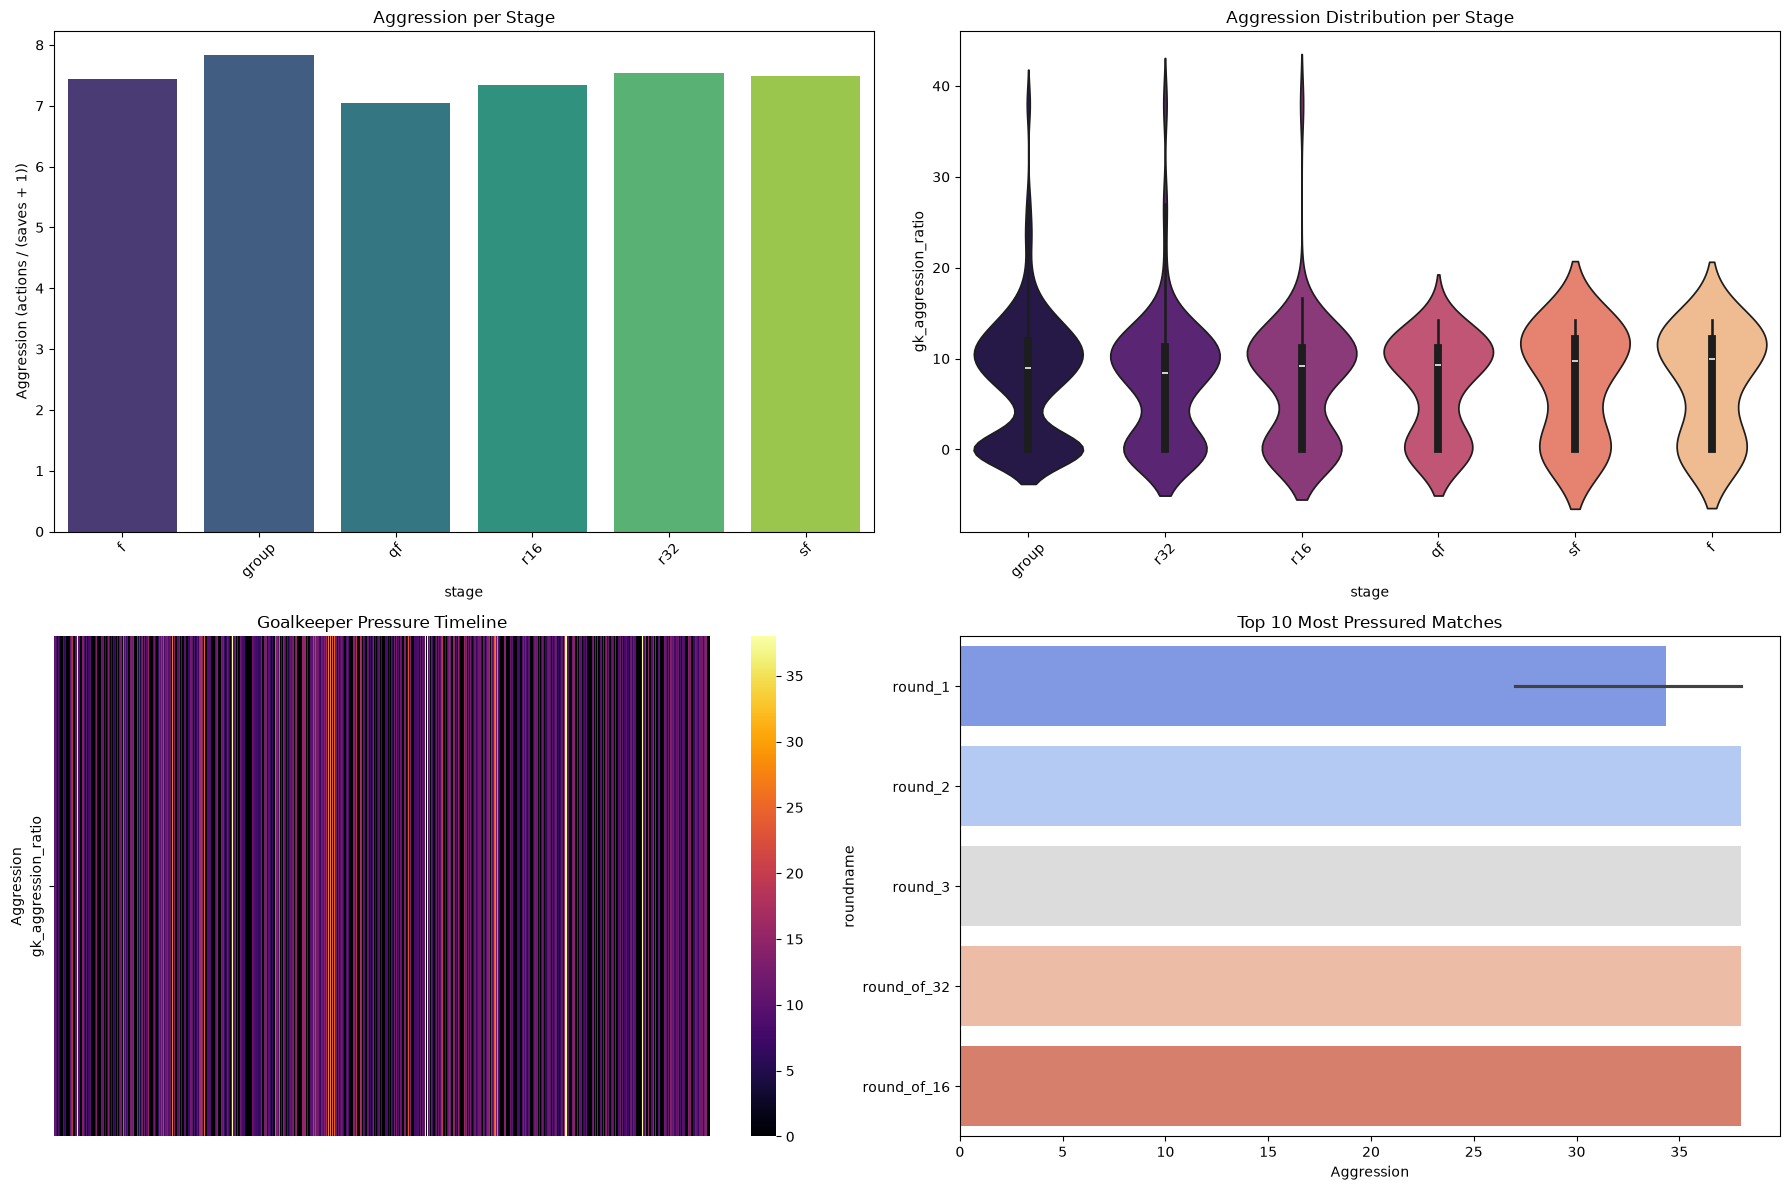

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. LOAD DATA
# -----------------------------
rounds = pd.read_csv("rounds.csv")
teams = pd.read_csv("teams.csv")
gk = pd.read_csv("goalkeeper.csv")

# -----------------------------
# 2. CLEAN COLUMN NAMES
# -----------------------------
rounds.columns = rounds.columns.str.strip().str.lower()
teams.columns = teams.columns.str.strip().str.lower()
gk.columns = gk.columns.str.strip().str.lower()

gk['team'] = gk['team'].str.strip()

# -----------------------------
# 3. MERGE GK STATS WITH TEAM ABBREVIATIONS
# -----------------------------
gk_stats = gk.merge(teams, left_on="team", right_on="abbr")

# -----------------------------
# 4. FIX HOME/AWAY ABBR COLUMNS
# -----------------------------
for col in rounds.columns:
    if "homesquadabbr" in col:
        rounds = rounds.rename(columns={col: "home_abbr"})
    if "awaysquadabbr" in col:
        rounds = rounds.rename(columns={col: "away_abbr"})

# -----------------------------
# 5. MERGE GK STATS INTO MATCHES
# -----------------------------
# HOME GK
rounds = rounds.merge(
    gk_stats[['abbr','goalkeeper_saves','goalkeeper_actions_inside_penaltyarea',
              'goalkeeper_actions_outside_penaltyarea']],
    left_on="home_abbr", right_on="abbr", how="left"
).rename(columns={
    "goalkeeper_saves": "home_saves",
    "goalkeeper_actions_inside_penaltyarea": "home_actions_in",
    "goalkeeper_actions_outside_penaltyarea": "home_actions_out"
}).drop(columns=["abbr"])

# AWAY GK
rounds = rounds.merge(
    gk_stats[['abbr','goalkeeper_saves','goalkeeper_actions_inside_penaltyarea',
              'goalkeeper_actions_outside_penaltyarea']],
    left_on="away_abbr", right_on="abbr", how="left"
).rename(columns={
    "goalkeeper_saves": "away_saves",
    "goalkeeper_actions_inside_penaltyarea": "away_actions_in",
    "goalkeeper_actions_outside_penaltyarea": "away_actions_out"
}).drop(columns=["abbr"])

# -----------------------------
# 6. COMPUTE AGGRESSION METRIC
# -----------------------------
rounds["gk_total_actions"] = (
    rounds["home_actions_in"] + rounds["home_actions_out"] +
    rounds["away_actions_in"] + rounds["away_actions_out"]
)

rounds["gk_total_saves"] = rounds["home_saves"] + rounds["away_saves"]

rounds["gk_aggression_ratio"] = rounds["gk_total_actions"] / (rounds["gk_total_saves"] + 1)

# -----------------------------
# 7. SORT MATCHES BY DATE
# -----------------------------
rounds["date"] = pd.to_datetime(rounds["date"])
timeline = rounds.sort_values("date")

# -----------------------------
# 8. BUILD DASHBOARD
# -----------------------------
plt.figure(figsize=(18,12))

# --- Plot 1: Aggression per stage ---
plt.subplot(2,2,1)
aggression_per_stage = rounds.groupby("stage")["gk_aggression_ratio"].mean().reset_index()
sns.barplot(data=aggression_per_stage, x="stage", y="gk_aggression_ratio", palette="viridis")
plt.title("Aggression per Stage")
plt.ylabel("Aggression (actions / (saves + 1))")
plt.xticks(rotation=45)

# --- Plot 2: Aggression distribution per stage ---
plt.subplot(2,2,2)
sns.violinplot(data=rounds, x="stage", y="gk_aggression_ratio", palette="magma")
plt.title("Aggression Distribution per Stage")
plt.xticks(rotation=45)

# --- Plot 3: Pressure heatmap timeline ---
plt.subplot(2,2,3)
sns.heatmap(
    timeline[["gk_aggression_ratio"]].T,
    cmap="inferno",
    cbar=True,
    xticklabels=False
)
plt.title("Goalkeeper Pressure Timeline")
plt.ylabel("Aggression")

# --- Plot 4: Top 10 most pressured matches ---
plt.subplot(2,2,4)
top10 = rounds.nlargest(10, "gk_aggression_ratio")
sns.barplot(
    data=top10,
    y="roundname",
    x="gk_aggression_ratio",
    palette="coolwarm"
)
plt.title("Top 10 Most Pressured Matches")
plt.xlabel("Aggression")

plt.tight_layout()
plt.show()
